# Checking out the results of our model
### Author: Shriansh Jain(S20230010225)

In [ ]:
import torch
from PIL import Image
from torchvision import transforms
from generator_model import Generator
import config

In [3]:
device = config.DEVICE
checkpoint_path = "goodmodels/gen.pth.tar"#config.CHECKPOINT_GEN
input_image_path = "maps/val/8.jpg"
output_image_path = "output.png"

In [4]:
print(device)

cuda


In [5]:
gen = Generator(in_channels=3, features=64).to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
gen.load_state_dict(checkpoint["state_dict"])
gen.eval()

Generator(
  (initial_down): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), padding_mode=reflect)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (down1): Block(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (down2): Block(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False, padding_mode=reflect)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (down3): Block(
    (conv): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False, pa

In [6]:
image = Image.open(input_image_path).convert('RGB')
w, h = image.size
input_image = image.crop((0, 0, w//2, h))  # Left half is input

In [7]:
transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ])
input_tensor = transform(input_image).unsqueeze(0).to(device)

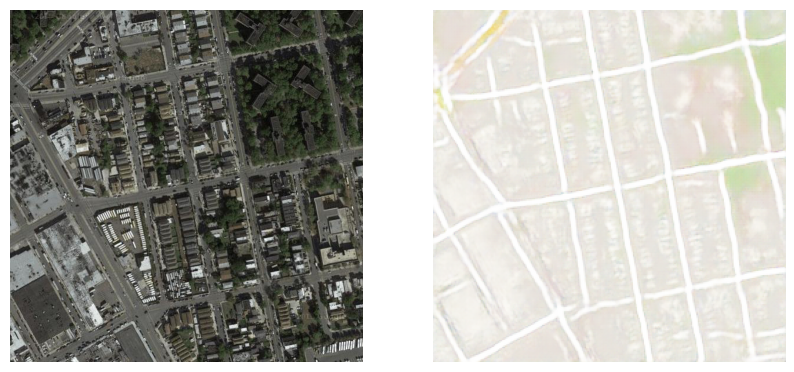

In [10]:
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

with torch.no_grad():
    output = gen(input_tensor)
    output = output * 0.5 + 0.5  # denormalize
    output_image = to_pil_image(output.squeeze(0))

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(input_image)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(output_image)
    plt.axis('off')

    plt.show()